# Classifying the 100K H&E dataset - 3

Method: Fine tuning DenseNet-121 architecture, transfer learning idea from [Tissue Type Recognition in Whole Slide Histological
Images](https://ceur-ws.org/Vol-3027/paper50.pdf)

DenseNet Tutorial: https://medium.com/@karuneshu21/implement-densenet-in-pytorch-46374ef91900 (not used because not trained)

Model: Pytorch [Densenet-121](https://docs.pytorch.org/vision/2.0/models/generated/torchvision.models.densenet121.html#:~:text=weights='IMAGENET1K_V1'%20.-,DenseNet121_Weights.,DEFAULT%20.&text=The%20inference%20transforms%20are%20available,0.229%2C%200.224%2C%200.225%5D%20.)

Data: [100,000 histological images of human colorectal cancer and healthy tissue](https://doi.org/10.5281/zenodo.1214456)

Author: Marissa Esteban

Date: 04/29/2026


In [29]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda
from torch.utils.data import DataLoader

In [40]:
# importing the data

batch_size = 64 # paper used 16 but too slow

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    root="D:\\me2982@cumc.columbia.edu\\bianca\\NCT-CRC-HE-100K",   # path to the unzipped folder
    # root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/NCT-CRC-HE-100K",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root="D:\\me2982@cumc.columbia.edu\\bianca\\CRC-VAL-HE-7K",
    # root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/CRC-VAL-HE-7K",
    transform=transform
)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=True, num_workers=0)

classes = train_dataset.classes

# Check it loaded correctly
print(train_dataset.classes)   # ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
print(len(train_dataset))      # 100000

['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
100000


In [31]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### Using pretrained Densenet121

In [32]:
import torchvision.models

In [42]:
densenet = torchvision.models.densenet121(weights='IMAGENET1K_V1')
densenet.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [35]:
densenet.classifier

Linear(in_features=1024, out_features=1000, bias=True)

In [43]:
# redefine the classifier
classifier = nn.Linear(in_features=1024, out_features=9, bias = True)
densenet.classifier = classifier
densenet.classifier

densenet = densenet.to(device)

In [44]:
# freeze all layers so we can train the last classification layer

for name, param in densenet.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

In [45]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(densenet.parameters(), lr=1e-5) # learning rate from the paper

In [46]:
# training the last layer of densenet

# training the network
train_losses = []
val_losses = []
val_accuracy = []

l2_lambda = 1e-4  # regularization strength

for epoch in range(10):  # paper trained for 10 epochs

    running_loss = 0.0
    epoch_loss = 0.0
    densenet.train()
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward
        outputs = densenet(inputs)
        loss = criterion(outputs, labels)

        # L2 regularization
        weights = 0
        for param in densenet.parameters():
            if param.requires_grad:  # only consider parameters that are being updated
                weights += torch.sum(param ** 2)

        # backward + optimize
        l2_loss = loss + l2_lambda * weights
        l2_loss.backward()
        optimizer.step()

        # update loss accumulators (for printing and evaluating)
        running_loss += l2_loss.item()
        epoch_loss += l2_loss.item()

        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0
        

    train_losses.append(epoch_loss / len(train_loader))
    
    # --- validation ---
    densenet.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = densenet(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_losses.append(val_loss / len(val_loader))
    val_accuracy.append(correct / total)
    print(f'Epoch {epoch + 1} complete | val loss: {val_losses[-1]:.3f}, val accuracy: {val_accuracy[-1]:.3f}')

print('Finished Training')

[1,   200] loss: 2.147
[1,   400] loss: 1.969
[1,   600] loss: 1.830
[1,   800] loss: 1.703
[1,  1000] loss: 1.581
[1,  1200] loss: 1.475
[1,  1400] loss: 1.384
Epoch 1 complete | val loss: 1.210, val accuracy: 0.808
[2,   200] loss: 1.230
[2,   400] loss: 1.159
[2,   600] loss: 1.102
[2,   800] loss: 1.047
[2,  1000] loss: 0.986
[2,  1200] loss: 0.945
[2,  1400] loss: 0.898
Epoch 2 complete | val loss: 0.793, val accuracy: 0.876
[3,   200] loss: 0.828
[3,   400] loss: 0.797
[3,   600] loss: 0.764
[3,   800] loss: 0.739
[3,  1000] loss: 0.707
[3,  1200] loss: 0.683
[3,  1400] loss: 0.659
Epoch 3 complete | val loss: 0.607, val accuracy: 0.897
[4,   200] loss: 0.616
[4,   400] loss: 0.611
[4,   600] loss: 0.585
[4,   800] loss: 0.568
[4,  1000] loss: 0.547
[4,  1200] loss: 0.551
[4,  1400] loss: 0.523
Epoch 4 complete | val loss: 0.492, val accuracy: 0.903
[5,   200] loss: 0.506
[5,   400] loss: 0.498
[5,   600] loss: 0.478
[5,   800] loss: 0.474
[5,  1000] loss: 0.472
[5,  1200] loss: 

In [48]:
import json

# save training and validation losses and accuracy to a json file
with open('D:\\me2982@cumc.columbia.edu\\bianca\\models\\densenet_losses.json', "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracy": val_accuracy
    }, f)

# saving our model
PATH = 'D:\\me2982@cumc.columbia.edu\\bianca\\models\\densenset_1.pth'
# PATH = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/models/densenet_phase_1.pth"
torch.save(densenet.state_dict(), PATH)

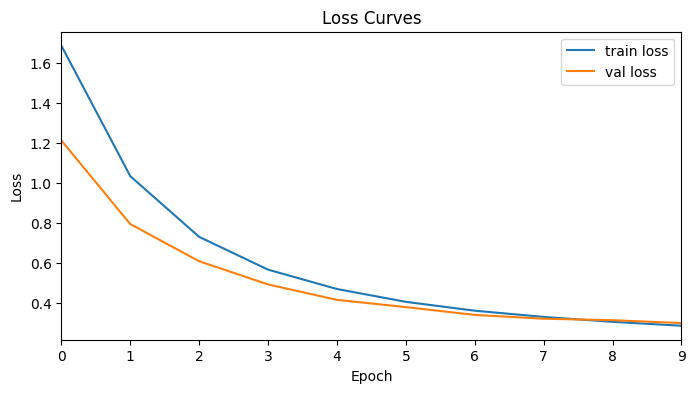

In [49]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.xlim(0, 9)
plt.show()

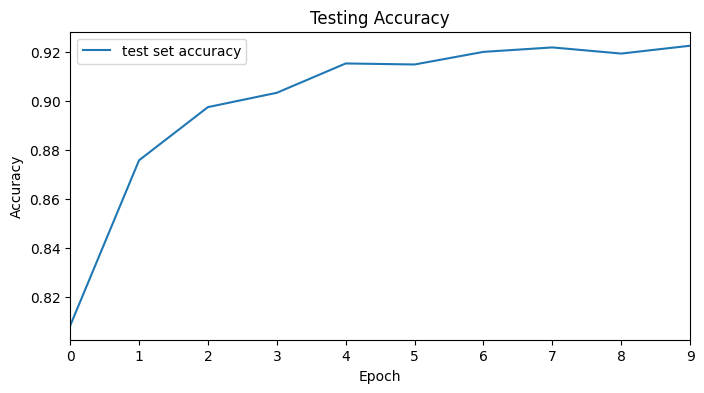

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(val_accuracy, label='test set accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Testing Accuracy')
plt.xlim(0, 9)
plt.show()

In [51]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = densenet(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 7000 validation images: {100 * correct // total} %')

KeyboardInterrupt: 

In [52]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

y_true = []
y_pred = []

# again no gradients needed
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        outputs = densenet(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            y_true.append(classes[label])
            y_pred.append(classes[prediction])
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: ADI   is 99.2 %
Accuracy for class: BACK  is 99.9 %
Accuracy for class: DEB   is 96.2 %
Accuracy for class: LYM   is 99.2 %
Accuracy for class: MUC   is 94.3 %
Accuracy for class: MUS   is 96.6 %
Accuracy for class: NORM  is 87.7 %
Accuracy for class: STR   is 37.5 %
Accuracy for class: TUM   is 92.5 %


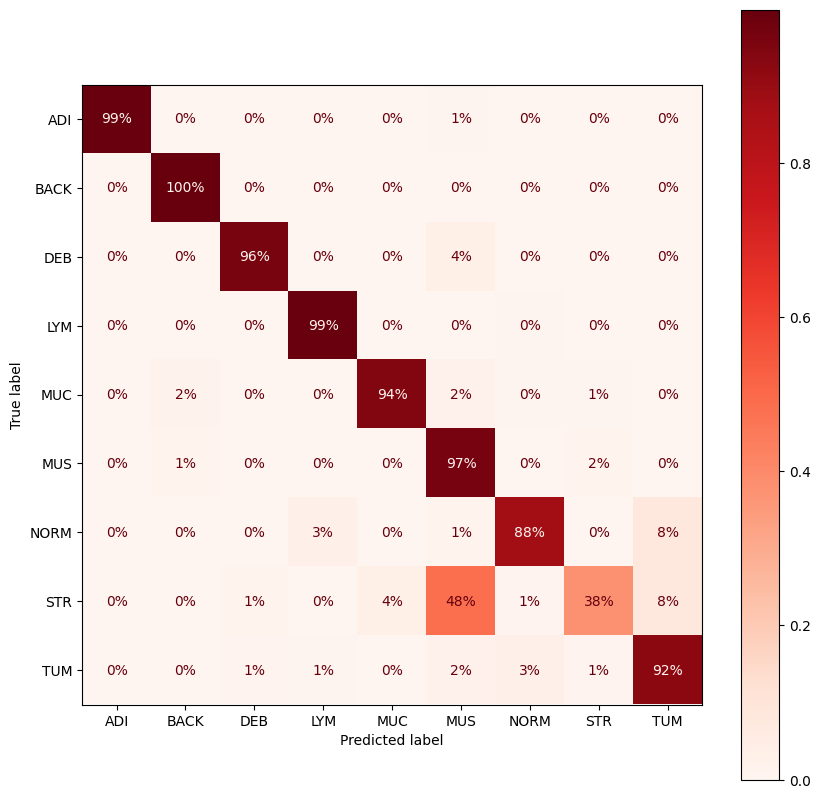

In [53]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format='.0%')

## Visualizing embeddings using uMAP

In [27]:
densenet

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
class densenetEmbedding(nn.Module):
    """
    Removing classfiication layer a
    """

    def __init__(self, densenet):
        super().__init__()
        self.features = densenet.features

    def forward(self, x):
        x = self.pool(F.relu(self.features(x)))    
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        
        return x

In [ ]:
densenet.eval()

embedding_net = densenetEmbedding(densenet).to(device)
embedding_net.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        emb = embedding_net(images)          # [32, 84]
        all_embeddings.append(emb.cpu())
        all_labels.append(labels)

# concatenate list of tensors into one matrix
X = torch.cat(all_embeddings).numpy()   # [7180, 84]
y = torch.cat(all_labels).numpy()       # [7180]

print(X.shape)  # (7180, 84)
print(y.shape)  # (7180,)

In [24]:
import umap
import umap.plot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\Marissa Esteban\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg,

In [27]:
mapper = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2).fit(X)

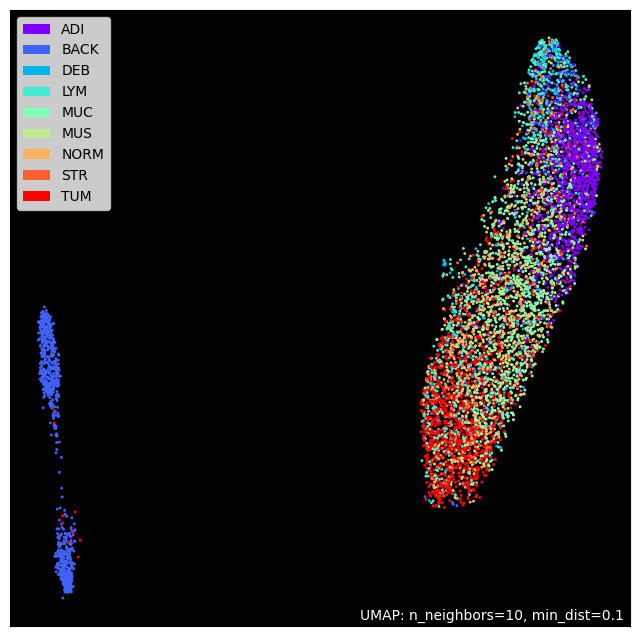

In [28]:
classes = ['ADI','BACK','DEB','LYM','MUC','MUS','NORM','STR','TUM']
y_named = np.array([classes[i] for i in y])

umap.plot.points(mapper, labels=y_named, theme='fire')
plt.show()